# 03 · Basic Machine-Learning Model — does census structure predict wave-2 COVID outcomes?

**Baseline design (deliberately simple & interpretable):** classical linear / logistic
models on the wave-2 cross-section (`wave2_model_table.csv` from notebook 01).
If a locality's *static* socio-economic profile carries real signal about its COVID
outcome, a linear model should already find it; if it does not, that is itself the
finding that motivates the improved model in notebook 04.

### 5 modelling tracks
`mean_IR`, `peak_IR`, `slope_to_peak_IR`, `severity_hosp_per_case` (regression) +
`severity_present` = `severity_hosp_per_case > 0` (classification — the ratio is
exactly 0 for ~87 % of areas, so a pure regression on it is dishonest).

### 4 model types → 110 fitted models
| stage | model | scope | count |
|-------|-------|-------|-------|
| 1 · univariate screen | Linear reg. (cont.) / Logistic reg. (`severity_present`) | one feature at a time, 19 features ✕ 5 tracks | 95 |
| 2 · combined | **Ridge** (cont.) / **L2-Logistic** | 3 feature sets (representatives / indices / both) ✕ 5 tracks | 15 |

* **GroupKFold by town** everywhere (never plain KFold): sub-areas of one city
  share static features + spatial correlation → plain CV would leak.
* Ridge / L2 instead of OLS because the domain representative and its PCA index are
  themselves correlated up to r ≈ 0.99.
* **Benjamini–Hochberg FDR** correction on each track's 19 univariate p-values —
  with 19 tests, ~1 "significant" hit is expected by chance alone.
* 19 of the 27 census features are usable here (`pop_density`, `inst_pcnt`,
  `Foreign_pcnt`, `change_pcnt` are near-empty at sub-area resolution — real source
  sparsity, verified against the raw census).

In [1]:
# --- repo bootstrap: make every path in this notebook repo-relative ---
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data" / "raw").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "data" / "raw").exists(), "launch this notebook from inside the repo"
os.chdir(PROJECT_ROOT)
print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /home/bcrlab/igguest/porat_naama


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import r2_score, roc_auc_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

TABLE_PATH = Path("data/processed/models/wave2_model_table.csv")
OUT_DIR = Path("data/processed/models")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_SPLITS = 5
RANDOM_STATE = 0
FDR_ALPHA = 0.05

REPRESENTATIVE_COLS = [
    "age65_pcnt", "j_isr_pcnt", "size_avg", "WrkY_pcnt",
    "employeesAnnual_medWage", "Vehicle2up_pcnt", "koshi5_pcnt",
]
INDEX_COLS = [
    "age_structure_idx", "origin_idx", "household_family_idx", "employment_idx",
    "income_idx", "housing_assets_idx", "disability_idx",
]
STANDALONE_COLS = ["pop_approx", "hh_total_approx", "sexRatio", "WrkOutLoc_pcnt", "AcadmCert_pcnt"]
FEATURE_COLS = REPRESENTATIVE_COLS + INDEX_COLS + STANDALONE_COLS  # 19

FEATURE_SETS = {
    "representatives": REPRESENTATIVE_COLS,
    "indices": INDEX_COLS,
    "both": FEATURE_COLS,
}

CONTINUOUS_TARGETS = ["mean_IR", "peak_IR", "slope_to_peak_IR", "severity_hosp_per_case"]

output_log = []

def log_output(path, description, description_he):
    output_log.append({"file_path": str(path), "contents": description, "contents_he": description_he})
    print("Saved:", path)

In [3]:
df = pd.read_csv(TABLE_PATH)
print(f"Loaded {len(df):,} areas, {df.shape[1]} columns")

df["town_code"] = df["City_agas_code"].str.split("_").str[0]

n_before = len(df)
df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"Rows with all {len(FEATURE_COLS)} features present: {len(df):,} / {n_before:,}")

lo, hi = df["slope_to_peak_IR"].quantile([0.01, 0.99])
n_clipped = ((df["slope_to_peak_IR"] < lo) | (df["slope_to_peak_IR"] > hi)).sum()
df["slope_to_peak_IR"] = df["slope_to_peak_IR"].clip(lo, hi)
print(f"Winsorized slope_to_peak_IR at [{lo:.4f}, {hi:.4f}] - {n_clipped} values clipped")

df["severity_present"] = (df["severity_hosp_per_case"] > 0).astype(int)
print(f"severity_present positive rate: {df['severity_present'].mean():.1%} ({df['severity_present'].sum()} / {len(df)})")

groups = df["town_code"].values
print(f"Grouped CV: {df['town_code'].nunique()} towns across {len(df)} areas")

X_raw = df[FEATURE_COLS].copy()
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_raw), columns=FEATURE_COLS, index=df.index)

Loaded 1,008 areas, 37 columns
Rows with all 19 features present: 816 / 1,008
Winsorized slope_to_peak_IR at [0.0003, 0.0402] - 18 values clipped
severity_present positive rate: 10.7% (87 / 816)
Grouped CV: 133 towns across 816 areas


In [4]:
def cv_r2(x_2d, y, groups, model_factory):
    gkf = GroupKFold(n_splits=N_SPLITS)
    y_pred = cross_val_predict(model_factory(), x_2d, y, cv=gkf, groups=groups)
    return r2_score(y, y_pred)


def cv_auc(x_2d, y, groups, model_factory):
    gkf = GroupKFold(n_splits=N_SPLITS)
    y_proba = cross_val_predict(model_factory(), x_2d, y, cv=gkf, groups=groups, method="predict_proba")[:, 1]
    return roc_auc_score(y, y_proba)

In [5]:
univariate_rows = []

for target in CONTINUOUS_TARGETS:
    y = df[target].values
    for feat in FEATURE_COLS:
        x_raw = X_raw[feat].values
        lr = stats.linregress(x_raw, y)
        r2_cv = cv_r2(x_raw.reshape(-1, 1), y, groups, LinearRegression)

        univariate_rows.append({
            "track": target,
            "feature": feat,
            "effect": lr.slope,
            "r_or_pseudo_r2": lr.rvalue,
            "r2_in_sample": lr.rvalue ** 2,
            "p_value": lr.pvalue,
            "cv_score": r2_cv,
        })

print(f"Continuous univariate rows so far: {len(univariate_rows)}")

Continuous univariate rows so far: 76


In [6]:
for feat in FEATURE_COLS:
    y = df["severity_present"].values
    x_raw = X_raw[feat].values
    x_with_const = sm.add_constant(x_raw)

    try:
        logit_model = sm.Logit(y, x_with_const).fit(disp=0)
        p_value = logit_model.pvalues[1]
        pseudo_r2 = logit_model.prsquared
    except Exception as e:
        print(f"  [severity_present ~ {feat}] statsmodels Logit failed ({e}); marking as NaN")
        p_value = np.nan
        pseudo_r2 = np.nan

    auc = cv_auc(
        x_raw.reshape(-1, 1), y, groups,
        lambda: LogisticRegression(class_weight="balanced", max_iter=1000),
    )

    univariate_rows.append({
        "track": "severity_present",
        "feature": feat,
        "effect": np.nan,
        "r_or_pseudo_r2": pseudo_r2,
        "r2_in_sample": pseudo_r2,
        "p_value": p_value,
        "cv_score": auc,
    })

univariate_results = pd.DataFrame(univariate_rows)
print(f"Total univariate rows: {len(univariate_results)}  (expected 19 features x 5 tracks = 95)")

Total univariate rows: 95  (expected 19 features x 5 tracks = 95)


In [7]:
univariate_results["p_fdr"] = np.nan
univariate_results["significant_fdr"] = False

for track, group_df in univariate_results.groupby("track"):
    valid = group_df["p_value"].notna()
    if valid.sum() == 0:
        continue
    rejected, p_fdr, _, _ = multipletests(group_df.loc[valid, "p_value"], alpha=FDR_ALPHA, method="fdr_bh")
    univariate_results.loc[group_df.index[valid], "p_fdr"] = p_fdr
    univariate_results.loc[group_df.index[valid], "significant_fdr"] = rejected

n_sig = univariate_results["significant_fdr"].sum()
print(f"Features significant after FDR correction (alpha={FDR_ALPHA}): {n_sig} / {len(univariate_results)}")
print(univariate_results[univariate_results["significant_fdr"]][["track", "feature", "p_value", "p_fdr"]])

univariate_path = OUT_DIR / "wave2_univariate_screen_results.csv"
univariate_results.to_csv(univariate_path, index=False, encoding="utf-8-sig")
log_output(
    univariate_path,
    "Stage 1: univariate screen. One row per (track x feature) - 19 features x 5 tracks = 95 rows. "
    "For the 4 continuous tracks: linear regression slope/r/R2/p-value (scipy.stats.linregress) + "
    "5-fold grouped-CV R2. For severity_present: logistic regression p-value + McFadden pseudo-R2 + "
    "5-fold grouped-CV AUC. p_fdr/significant_fdr are Benjamini-Hochberg corrected within each track's "
    "19 p-values separately.",
    "שלב 1: סריקה חד-משתנית. שורה לכל (מסלול x פיצ'ר) - 19 פיצ'רים x 5 מסלולים = 95 שורות. "
    "ל-4 המסלולים הרציפים: שיפוע/r/R2/p-value מרגרסיה ליניארית (scipy.stats.linregress) + "
    "R2 מ-5-fold grouped-CV. ל-severity_present: p-value מרגרסיה לוגיסטית + McFadden pseudo-R2 + "
    "AUC מ-5-fold grouped-CV. p_fdr/significant_fdr הם תיקון Benjamini-Hochberg בתוך 19 ה-p-values "
    "של כל מסלול בנפרד.",
)

Features significant after FDR correction (alpha=0.05): 57 / 95
                     track                  feature        p_value  \
0                  mean_IR               age65_pcnt   1.140568e-33   
1                  mean_IR               j_isr_pcnt   1.108108e-18   
2                  mean_IR                 size_avg   9.895759e-79   
3                  mean_IR                WrkY_pcnt   1.086002e-38   
4                  mean_IR  employeesAnnual_medWage   8.648684e-41   
5                  mean_IR          Vehicle2up_pcnt   7.882825e-25   
6                  mean_IR              koshi5_pcnt   2.367578e-04   
7                  mean_IR        age_structure_idx   1.011821e-81   
8                  mean_IR               origin_idx   3.543573e-23   
9                  mean_IR     household_family_idx  3.235796e-127   
10                 mean_IR           employment_idx   1.508316e-57   
11                 mean_IR               income_idx   1.282470e-32   
12                 mean_IR

In [8]:
combined_rows = []

for set_name, cols in FEATURE_SETS.items():
    X_set = X_scaled[cols].values

    for target in CONTINUOUS_TARGETS:
        y = df[target].values
        model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
        r2_cv_score = cv_r2(X_set, y, groups, lambda: Ridge(alpha=1.0, random_state=RANDOM_STATE))
        model.fit(X_set, y)
        r2_in = r2_score(y, model.predict(X_set))
        combined_rows.append({
            "track": target, "feature_set": set_name, "n_features": len(cols),
            "cv_score": r2_cv_score, "in_sample_score": r2_in, "overfit_gap": r2_in - r2_cv_score,
        })

    y = df["severity_present"].values
    model = LogisticRegression(penalty="l2", C=1.0, class_weight="balanced", max_iter=1000)
    auc_cv = cv_auc(X_set, y, groups, lambda: LogisticRegression(penalty="l2", C=1.0, class_weight="balanced", max_iter=1000))
    model.fit(X_set, y)
    auc_in = roc_auc_score(y, model.predict_proba(X_set)[:, 1])
    combined_rows.append({
        "track": "severity_present", "feature_set": set_name, "n_features": len(cols),
        "cv_score": auc_cv, "in_sample_score": auc_in, "overfit_gap": auc_in - auc_cv,
    })

combined_results = pd.DataFrame(combined_rows)
print(combined_results.round(3))

combined_path = OUT_DIR / "wave2_combined_regression_results.csv"
combined_results.to_csv(combined_path, index=False, encoding="utf-8-sig")
log_output(
    combined_path,
    "Stage 2: combined regression. One row per (feature-set x track) - 3 feature-sets x 5 tracks = "
    "15 rows. Ridge regression for the 4 continuous tracks (cv_score/in_sample_score = R2), "
    "L2-penalized Logistic Regression for severity_present (cv_score/in_sample_score = AUC). "
    "overfit_gap = in_sample_score - cv_score.",
    "שלב 2: רגרסיה משולבת. שורה לכל (קבוצת-פיצ'רים x מסלול) - 3 קבוצות x 5 מסלולים = 15 שורות. "
    "רגרסיית Ridge ל-4 המסלולים הרציפים (cv_score/in_sample_score = R2), רגרסיה לוגיסטית עם "
    "רגולריזציית L2 ל-severity_present (cv_score/in_sample_score = AUC). "
    "overfit_gap = in_sample_score - cv_score.",
)

                     track      feature_set  n_features  cv_score  \
0                  mean_IR  representatives           7     0.573   
1                  peak_IR  representatives           7     0.032   
2         slope_to_peak_IR  representatives           7    -0.026   
3   severity_hosp_per_case  representatives           7     0.035   
4         severity_present  representatives           7     0.778   
5                  mean_IR          indices           7     0.578   
6                  peak_IR          indices           7     0.023   
7         slope_to_peak_IR          indices           7    -0.030   
8   severity_hosp_per_case          indices           7     0.041   
9         severity_present          indices           7     0.758   
10                 mean_IR             both          19     0.617   
11                 peak_IR             both          19     0.032   
12        slope_to_peak_IR             both          19    -0.061   
13  severity_hosp_per_case        

## Figures — screens, FDR, summary
*(each cell writes a PNG to `data/processed/models/figures/`; the gallery cell renders them inline)*

In [9]:
TRACK_COLORS = {
    "mean_IR": "#2E6F95", "peak_IR": "#C1440E", "slope_to_peak_IR": "#5A8F3C",
    "severity_hosp_per_case": "#8E44AD", "severity_present": "#B8860B",
}
ALL_TRACKS = CONTINUOUS_TARGETS + ["severity_present"]

In [10]:
for target in ALL_TRACKS:
    sub = univariate_results[univariate_results["track"] == target].set_index("feature").reindex(FEATURE_COLS)
    metric = sub["r2_in_sample"]
    colors = ["#2E6F95" if sig else "#B0B0B0" for sig in sub["significant_fdr"]]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(sub.index, metric, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    metric_label = "AUC contribution (pseudo-R2)" if target == "severity_present" else "R2 (in-sample, single feature)"
    ax.set_xlabel(metric_label)
    ax.set_title(f"Univariate screen: {target}\n(blue = significant after FDR correction, alpha={FDR_ALPHA})")
    plt.tight_layout()
    fname = FIG_DIR / f"univariate_{target}.png"
    fig.savefig(fname, dpi=150)
    plt.close(fig)
    print("Saved:", fname)

Saved: data/processed/models/figures/univariate_mean_IR.png
Saved: data/processed/models/figures/univariate_peak_IR.png
Saved: data/processed/models/figures/univariate_slope_to_peak_IR.png
Saved: data/processed/models/figures/univariate_severity_hosp_per_case.png
Saved: data/processed/models/figures/univariate_severity_present.png


In [11]:
corr_matrix = pd.DataFrame(index=FEATURE_COLS, columns=ALL_TRACKS, dtype=float)
for target in ALL_TRACKS:
    for feat in FEATURE_COLS:
        corr_matrix.loc[feat, target] = np.corrcoef(X_raw[feat], df[target])[0, 1]

fig, ax = plt.subplots(figsize=(7, 8))
vmax = np.nanmax(np.abs(corr_matrix.values))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(ALL_TRACKS)))
ax.set_xticklabels(ALL_TRACKS, rotation=30, ha="right")
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(FEATURE_COLS)
ax.set_title("Pearson r: each census feature x each covid track")
fig.colorbar(im, ax=ax, label="r")
plt.tight_layout()
fname = FIG_DIR / "feature_target_correlation_heatmap.png"
fig.savefig(fname, dpi=150)
plt.close(fig)
print("Saved:", fname)

Saved: data/processed/models/figures/feature_target_correlation_heatmap.png


In [12]:
pivot_cont = combined_results[combined_results["track"] != "severity_present"].pivot(
    index="track", columns="feature_set", values="cv_score"
).reindex(CONTINUOUS_TARGETS)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(CONTINUOUS_TARGETS))
width = 0.25
set_colors = {"representatives": "#2a78d6", "indices": "#eb6834", "both": "#1baf7a"}
for i, set_name in enumerate(["representatives", "indices", "both"]):
    ax.bar(x + (i - 1) * width, pivot_cont[set_name], width, label=set_name, color=set_colors[set_name])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(CONTINUOUS_TARGETS, rotation=15, ha="right")
ax.set_ylabel("5-fold grouped CV R²")
ax.set_title("Combined regression (Ridge): CV R² by feature-set, continuous tracks")
ax.legend()
plt.tight_layout()
fname = FIG_DIR / "combined_regression_continuous_summary.png"
fig.savefig(fname, dpi=150)
plt.close(fig)
print("Saved:", fname)

Saved: data/processed/models/figures/combined_regression_continuous_summary.png


In [13]:
sub = combined_results[combined_results["track"] == "severity_present"].set_index("feature_set").reindex(["representatives", "indices", "both"])
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(sub.index, sub["cv_score"], color=[set_colors[s] for s in sub.index])
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--", label="random guessing (AUC=0.5)")
ax.set_ylabel("5-fold grouped CV AUC")
ax.set_title("Combined regression (Logistic): CV AUC by feature-set\nseverity_present")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
fname = FIG_DIR / "combined_regression_classification_summary.png"
fig.savefig(fname, dpi=150)
plt.close(fig)
print("Saved:", fname)

Saved: data/processed/models/figures/combined_regression_classification_summary.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, target in zip(axes, ALL_TRACKS):
    sub = univariate_results[univariate_results["track"] == target].dropna(subset=["p_value"]).copy()
    sub = sub.sort_values("p_value").reset_index(drop=True)
    m = len(sub)
    ranks = np.arange(1, m + 1)
    bh_line = (ranks / m) * FDR_ALPHA

    colors = ["#2E6F95" if sig else "#B0B0B0" for sig in sub["significant_fdr"]]
    ax.scatter(ranks, sub["p_value"], color=colors, zorder=3, s=40)
    ax.plot(ranks, bh_line, "k--", linewidth=1.2, label=f"BH threshold (i/{m})×{FDR_ALPHA}")
    ax.set_title(target, fontsize=10)
    ax.set_xlabel("rank (sorted by p-value)")
    ax.set_ylabel("p-value")
    ax.legend(fontsize=8)

for ax in axes[len(ALL_TRACKS):]:
    ax.axis("off")

fig.suptitle("Benjamini-Hochberg FDR correction: raw p-value vs. rank-dependent threshold", fontsize=13)
plt.tight_layout()
fname = FIG_DIR / "fdr_correction_illustration.png"
fig.savefig(fname, dpi=150)
plt.close(fig)
print("Saved:", fname)

Saved: data/processed/models/figures/fdr_correction_illustration.png


In [15]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

NAVY, ACCENT, LIGHT = "#1F2A44", "#2E6F95", "#EAF1F4"

def box(ax, x, y, w, h, text, fc=LIGHT, ec=ACCENT, fs=11, bold=True):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.04",
                        linewidth=1.8, edgecolor=ec, facecolor=fc, zorder=2)
    ax.add_patch(b)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs,
            color=NAVY, fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="-|>", mutation_scale=16,
                                  linewidth=1.8, color=ACCENT, zorder=1))

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.5); ax.axis("off")

box(ax, 0.3, 2.2, 2.3, 1.4, "wave2_model_table.csv\n1,008 areas x\n19 features + 5 targets")
arrow(ax, 2.7, 2.9, 3.55, 2.9)

box(ax, 3.6, 3.3, 2.6, 1.2, "Stage 1\nunivariate screen\n19 features x 5 tracks = 95")
box(ax, 3.6, 1.1, 2.6, 1.2, "Stage 2\ncombined regression\n3 sets x 5 tracks = 15")
arrow(ax, 6.3, 3.9, 7.35, 3.9)
arrow(ax, 6.3, 1.7, 7.35, 1.7)

box(ax, 7.4, 3.3, 2.5, 1.2, "FDR correction\n(per track, 19 p-values)", fc="#FFF3E0")
box(ax, 7.4, 1.1, 2.5, 1.2, "Ridge / Logistic\n(collinearity-safe)", fc="#FFF3E0")
arrow(ax, 10.0, 3.9, 10.9, 2.9)
arrow(ax, 10.0, 1.7, 10.9, 2.5)

box(ax, 11.0, 2.2, 1.7, 1.4, "results +\nfigures", fc="#FFFFFF", ec=NAVY)

ax.text(6.65, 5.1, "110 models total (95 univariate + 15 combined)", ha="center", fontsize=12,
        fontweight="bold", color=NAVY)

plt.tight_layout()
fname = FIG_DIR / "modeling_pipeline_diagram.png"
fig.savefig(fname, dpi=150)
plt.close(fig)
print("Saved:", fname)

Saved: data/processed/models/figures/modeling_pipeline_diagram.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 8), gridspec_kw={"width_ratios": [1, 0.55]})

# --- Panel 1: univariate CV R^2, 19 features x 4 continuous targets ---
uni_pivot = univariate_results[univariate_results["track"] != "severity_present"].pivot(
    index="feature", columns="track", values="cv_score"
).reindex(index=FEATURE_COLS, columns=CONTINUOUS_TARGETS)
sig_pivot = univariate_results[univariate_results["track"] != "severity_present"].pivot(
    index="feature", columns="track", values="significant_fdr"
).reindex(index=FEATURE_COLS, columns=CONTINUOUS_TARGETS)

vmax1 = np.nanmax(np.abs(uni_pivot.values))
im1 = ax1.imshow(uni_pivot.values, cmap="RdBu_r", vmin=-vmax1, vmax=vmax1, aspect="auto")
ax1.set_xticks(range(len(CONTINUOUS_TARGETS)))
ax1.set_xticklabels(CONTINUOUS_TARGETS, rotation=30, ha="right")
ax1.set_yticks(range(len(FEATURE_COLS)))
ax1.set_yticklabels(FEATURE_COLS)
ax1.set_title("Stage 1: univariate CV R²\n(* = significant after FDR)")
for i in range(uni_pivot.shape[0]):
    for j in range(uni_pivot.shape[1]):
        val = uni_pivot.values[i, j]
        star = "*" if sig_pivot.values[i, j] else ""
        ax1.text(j, i, f"{val:.2f}{star}", ha="center", va="center", fontsize=7,
                  color="white" if abs(val) > vmax1 * 0.6 else "black")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label="CV R²")

# --- Panel 2: combined CV R^2, 3 feature-sets x 4 continuous targets ---
comb_pivot = combined_results[combined_results["track"] != "severity_present"].pivot(
    index="feature_set", columns="track", values="cv_score"
).reindex(index=["representatives", "indices", "both"], columns=CONTINUOUS_TARGETS)

vmax2 = np.nanmax(np.abs(comb_pivot.values))
im2 = ax2.imshow(comb_pivot.values, cmap="RdBu_r", vmin=-vmax2, vmax=vmax2, aspect="auto")
ax2.set_xticks(range(len(CONTINUOUS_TARGETS)))
ax2.set_xticklabels(CONTINUOUS_TARGETS, rotation=30, ha="right")
ax2.set_yticks(range(len(comb_pivot.index)))
ax2.set_yticklabels(comb_pivot.index)
ax2.set_title("Stage 2: combined CV R²")
for i in range(comb_pivot.shape[0]):
    for j in range(comb_pivot.shape[1]):
        val = comb_pivot.values[i, j]
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                  color="white" if abs(val) > vmax2 * 0.6 else "black")
fig.colorbar(im2, ax=ax2, fraction=0.08, pad=0.04, label="CV R²")

fig.suptitle("R² summary across all regression tracks (severity_present excluded - AUC scale)", fontsize=13)
plt.tight_layout()
fname = FIG_DIR / "r2_results_heatmap_summary.png"
fig.savefig(fname, dpi=150)
plt.close(fig)
print("Saved:", fname)

Saved: data/processed/models/figures/r2_results_heatmap_summary.png


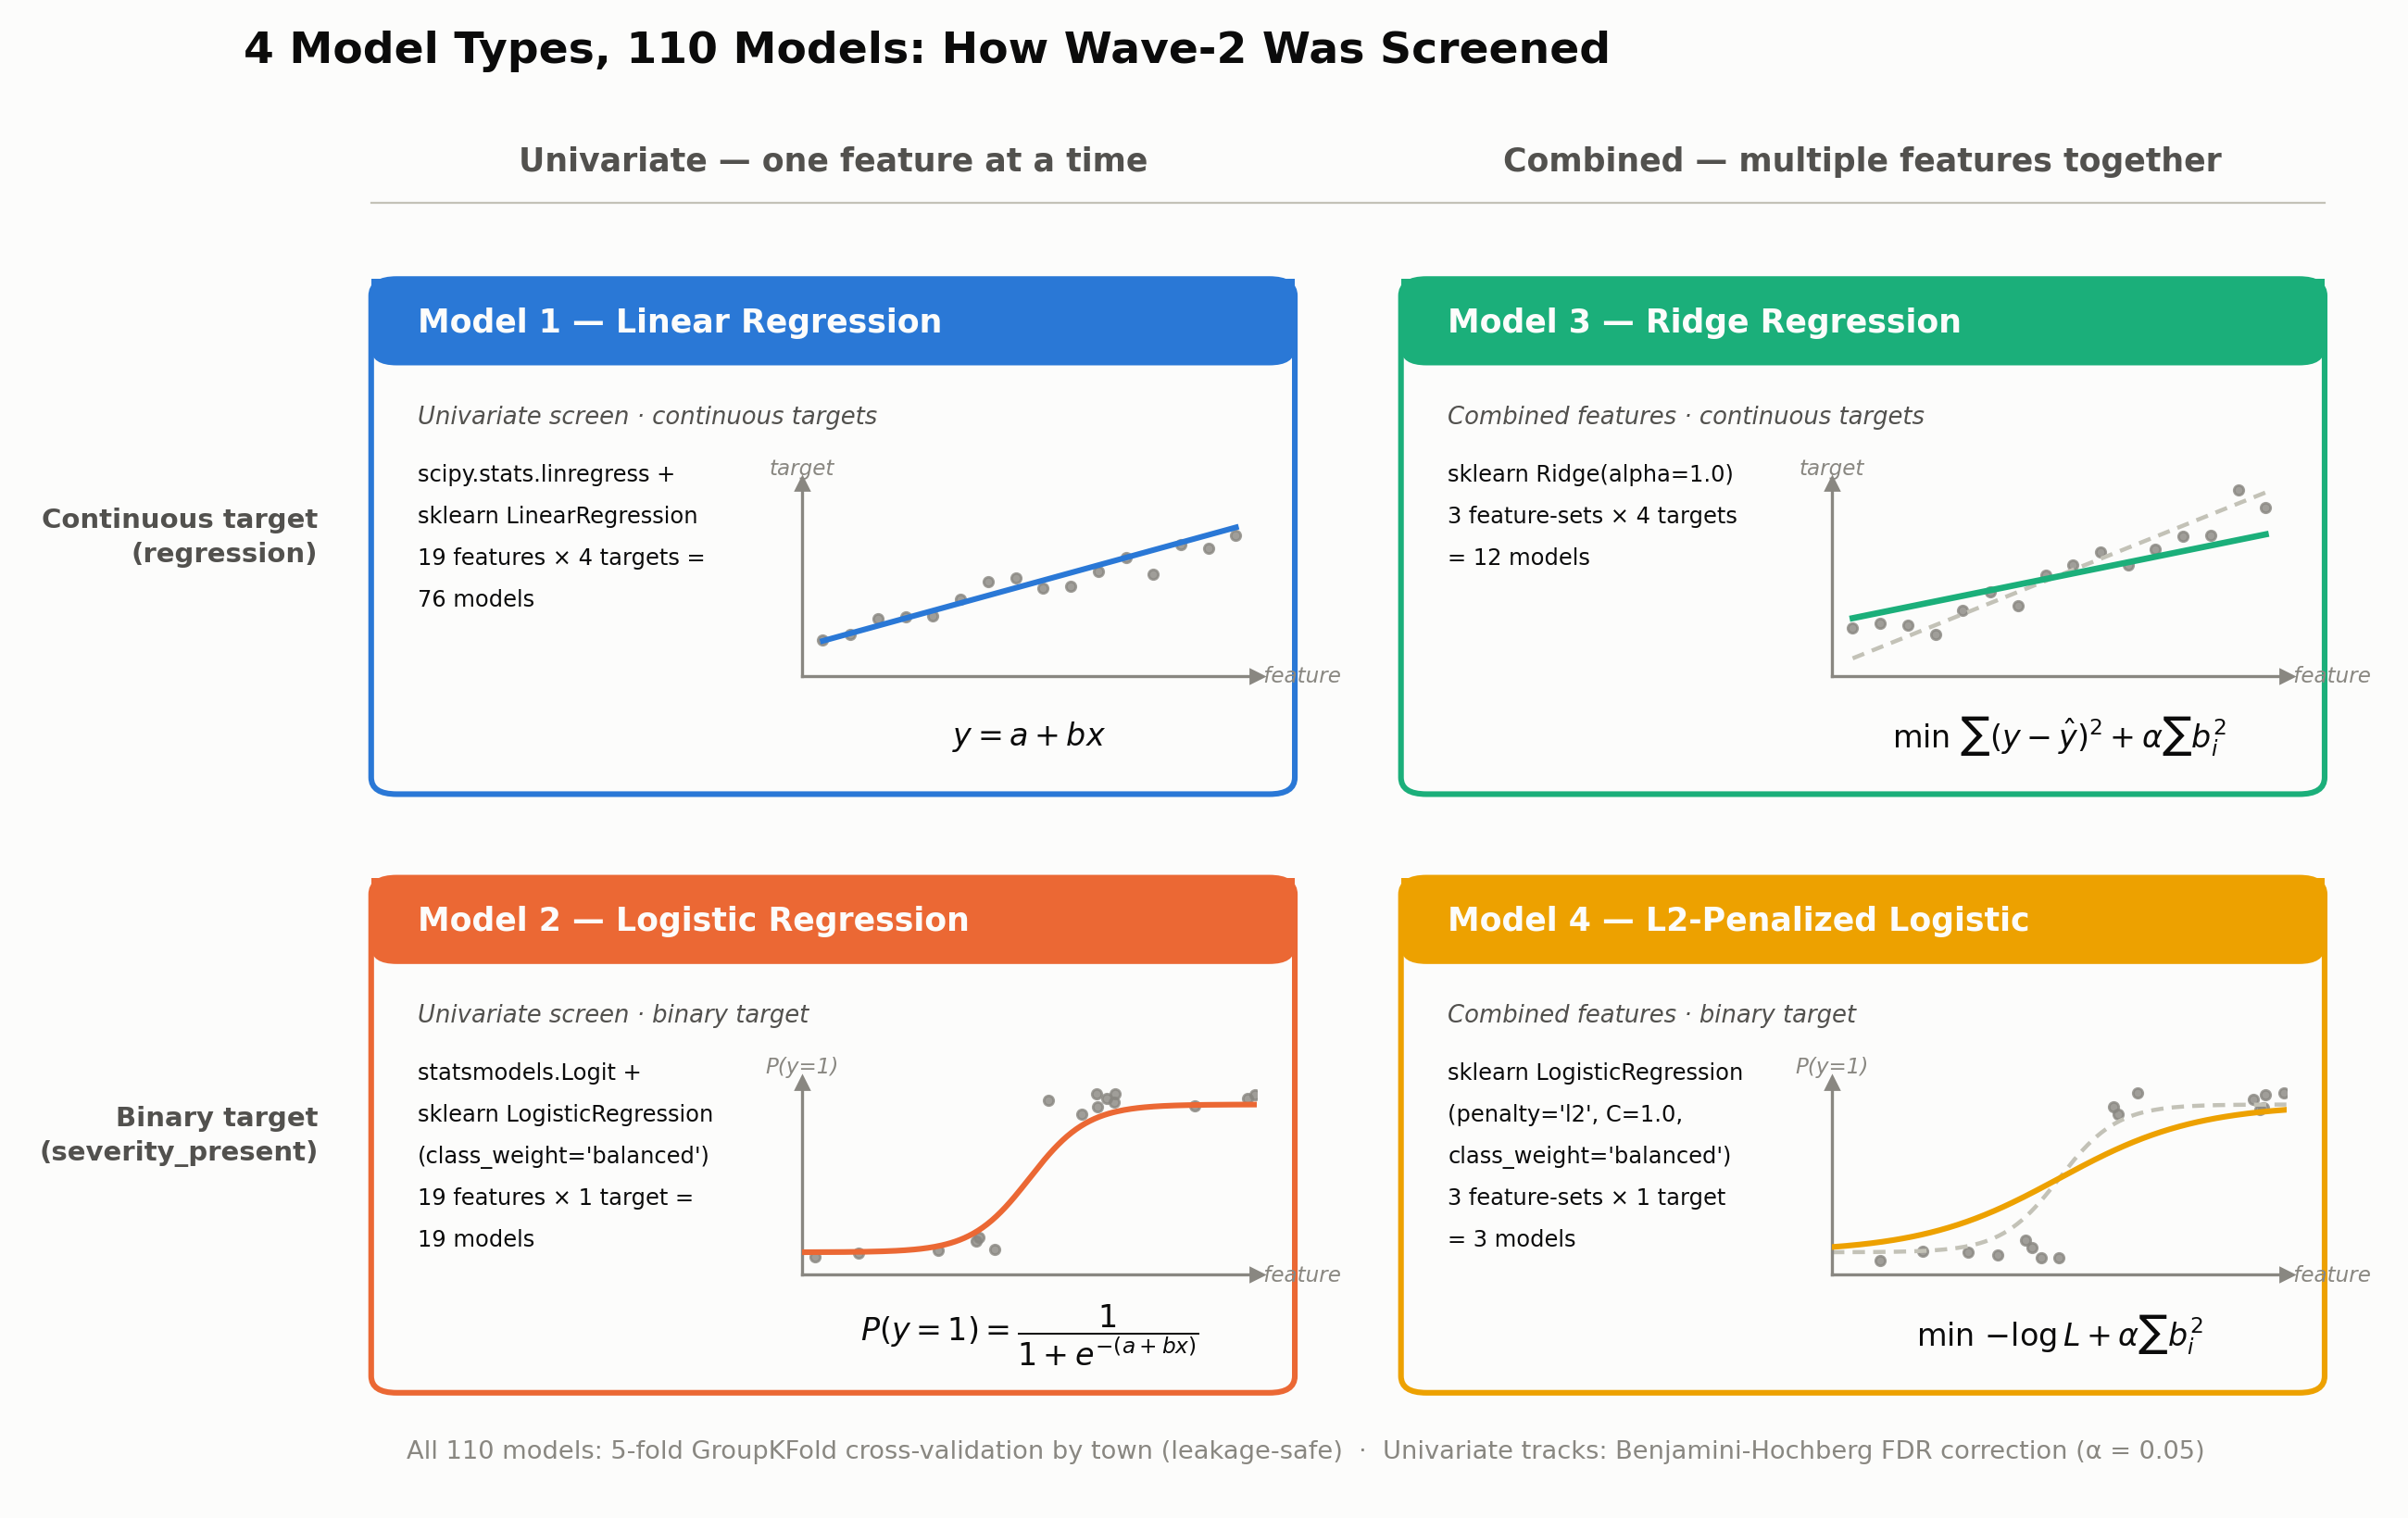

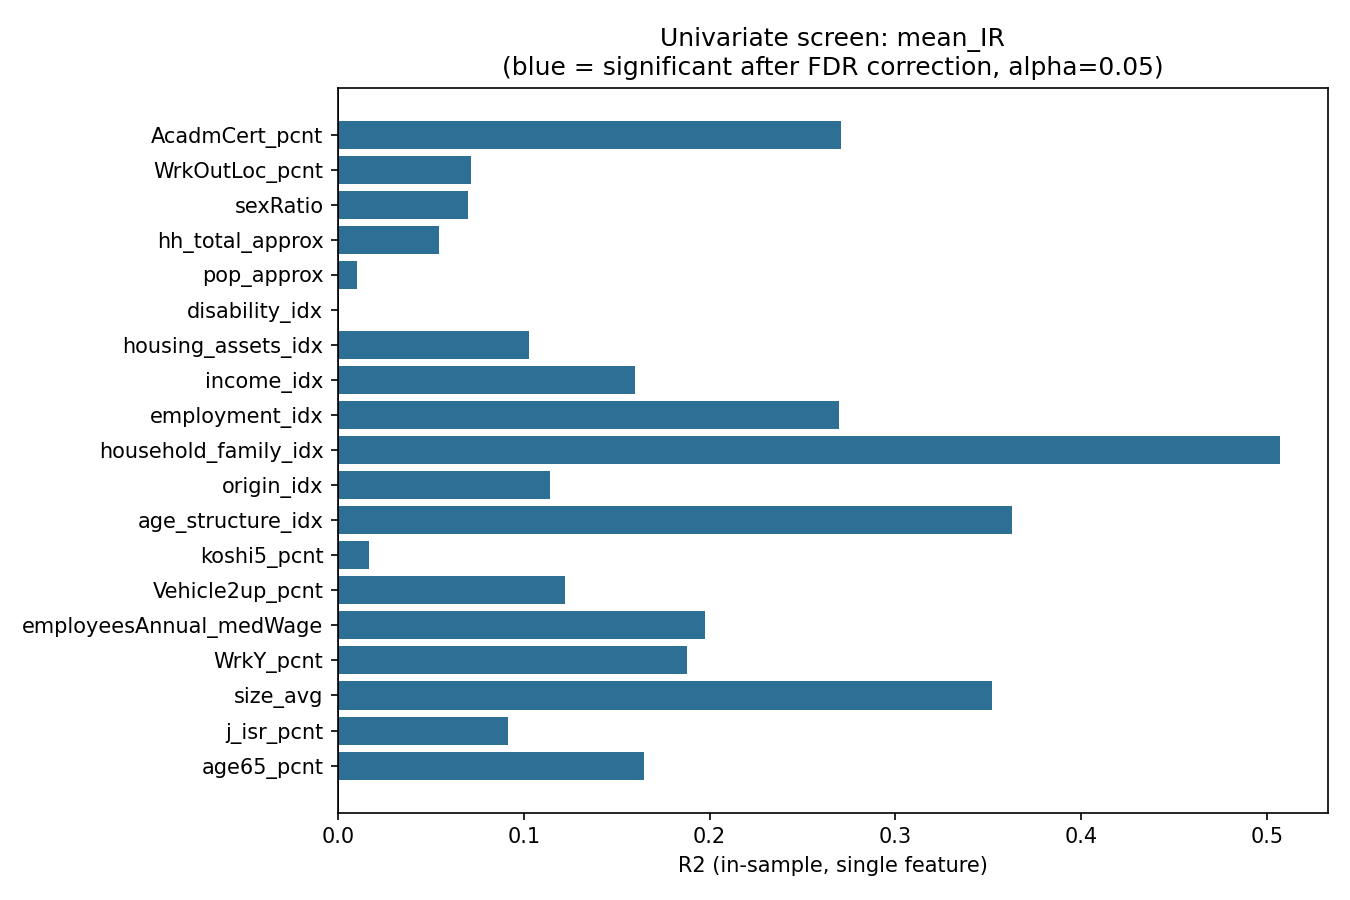

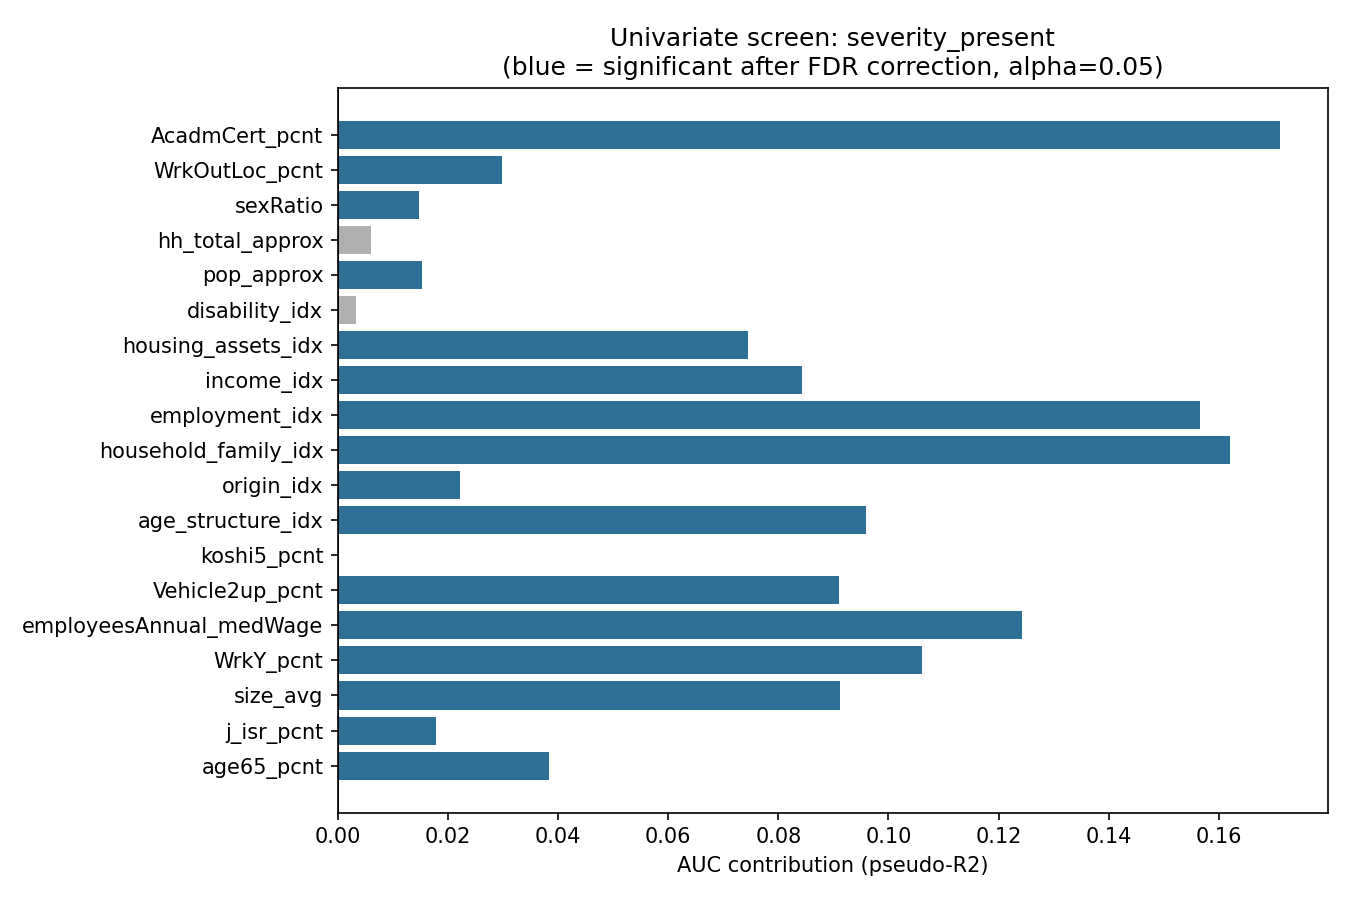

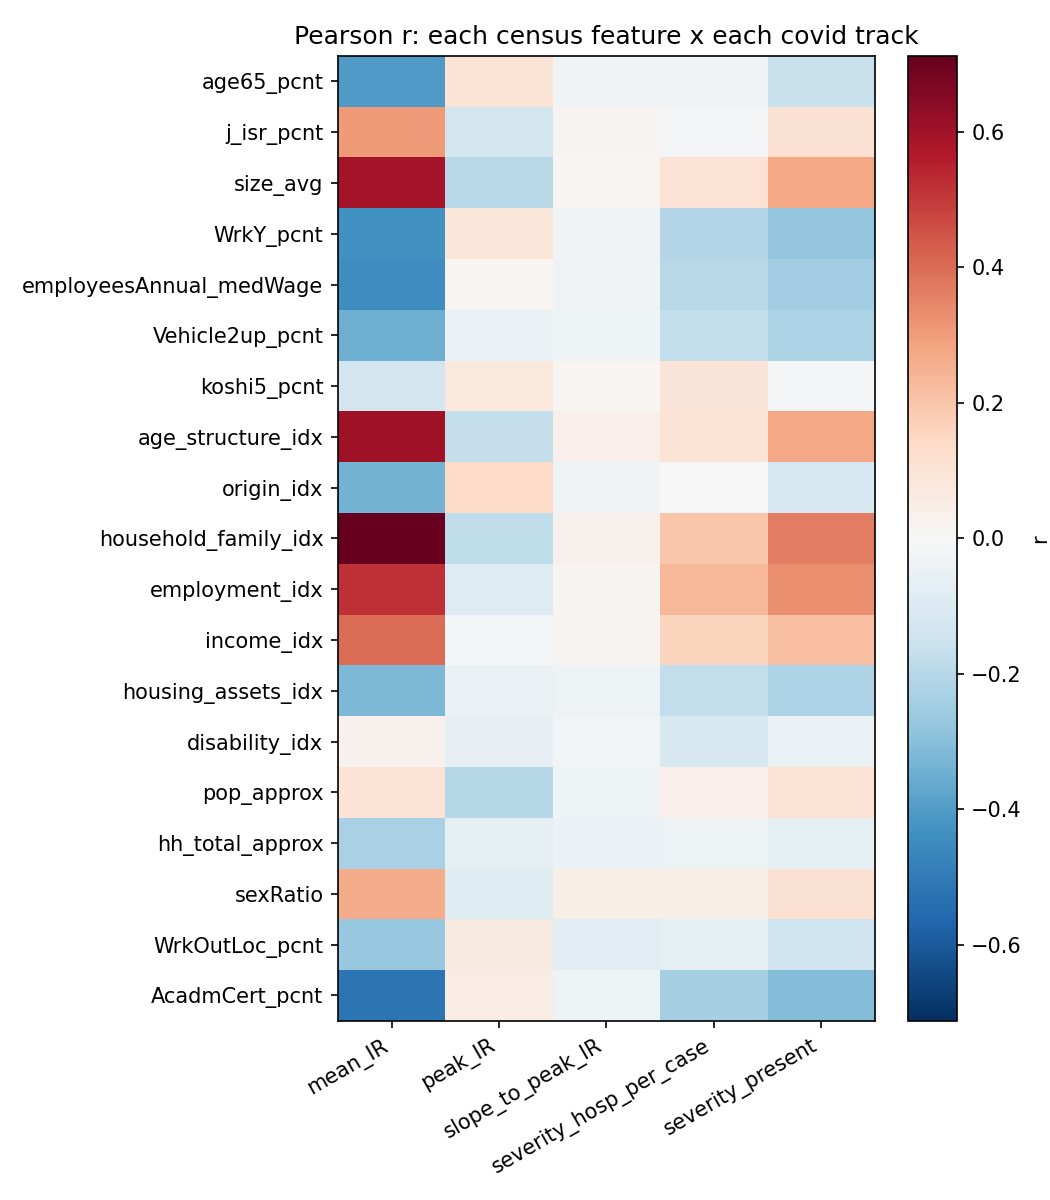

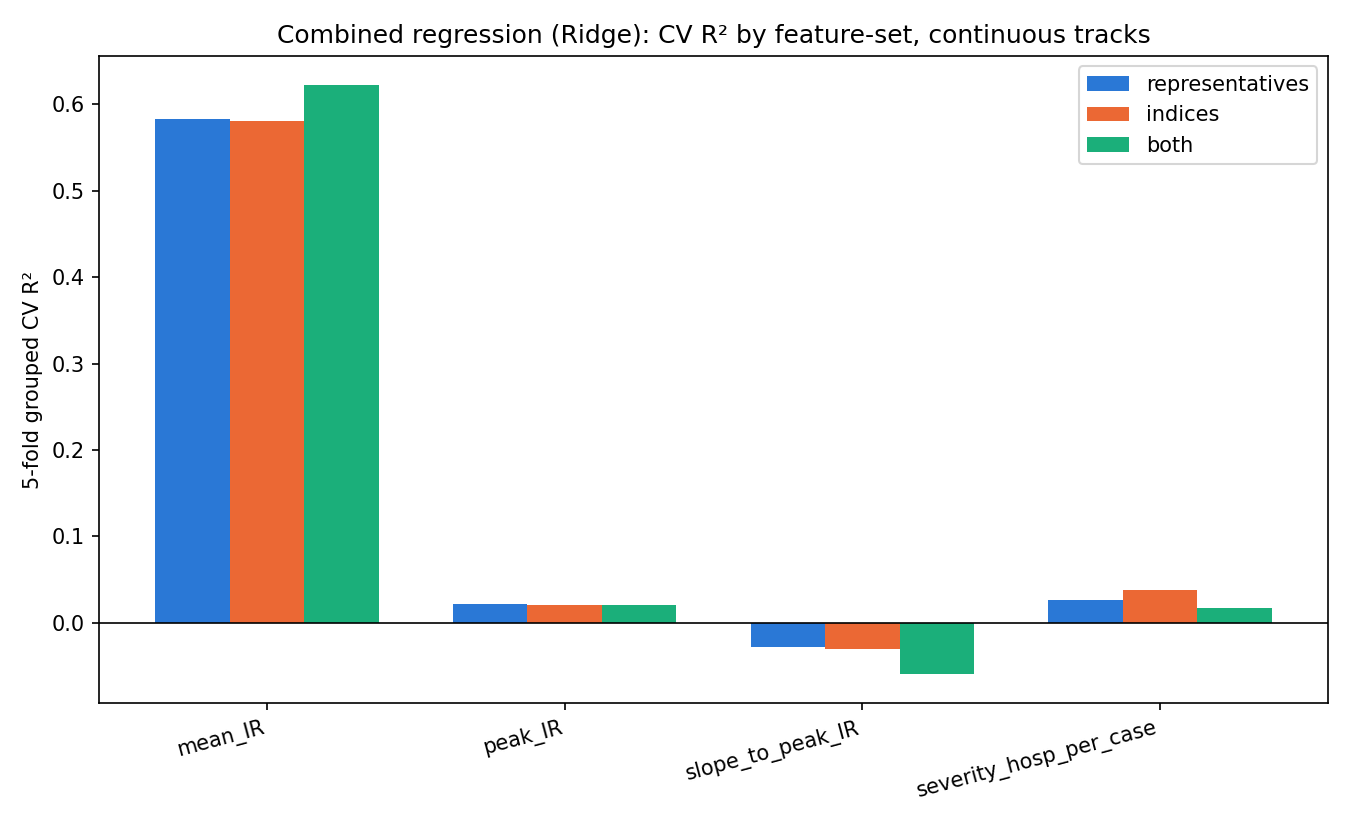

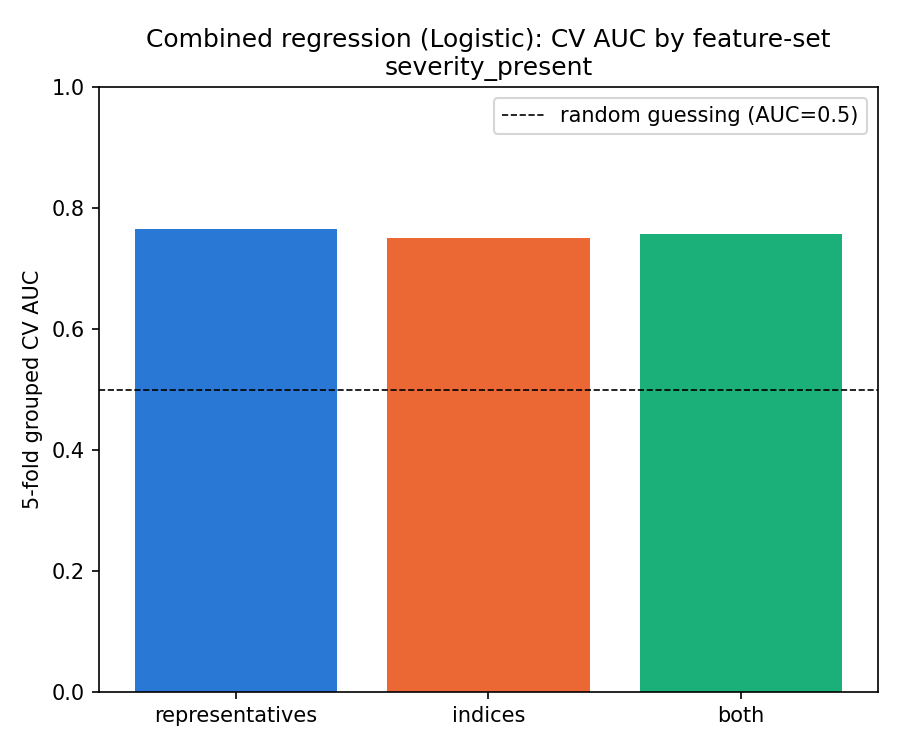

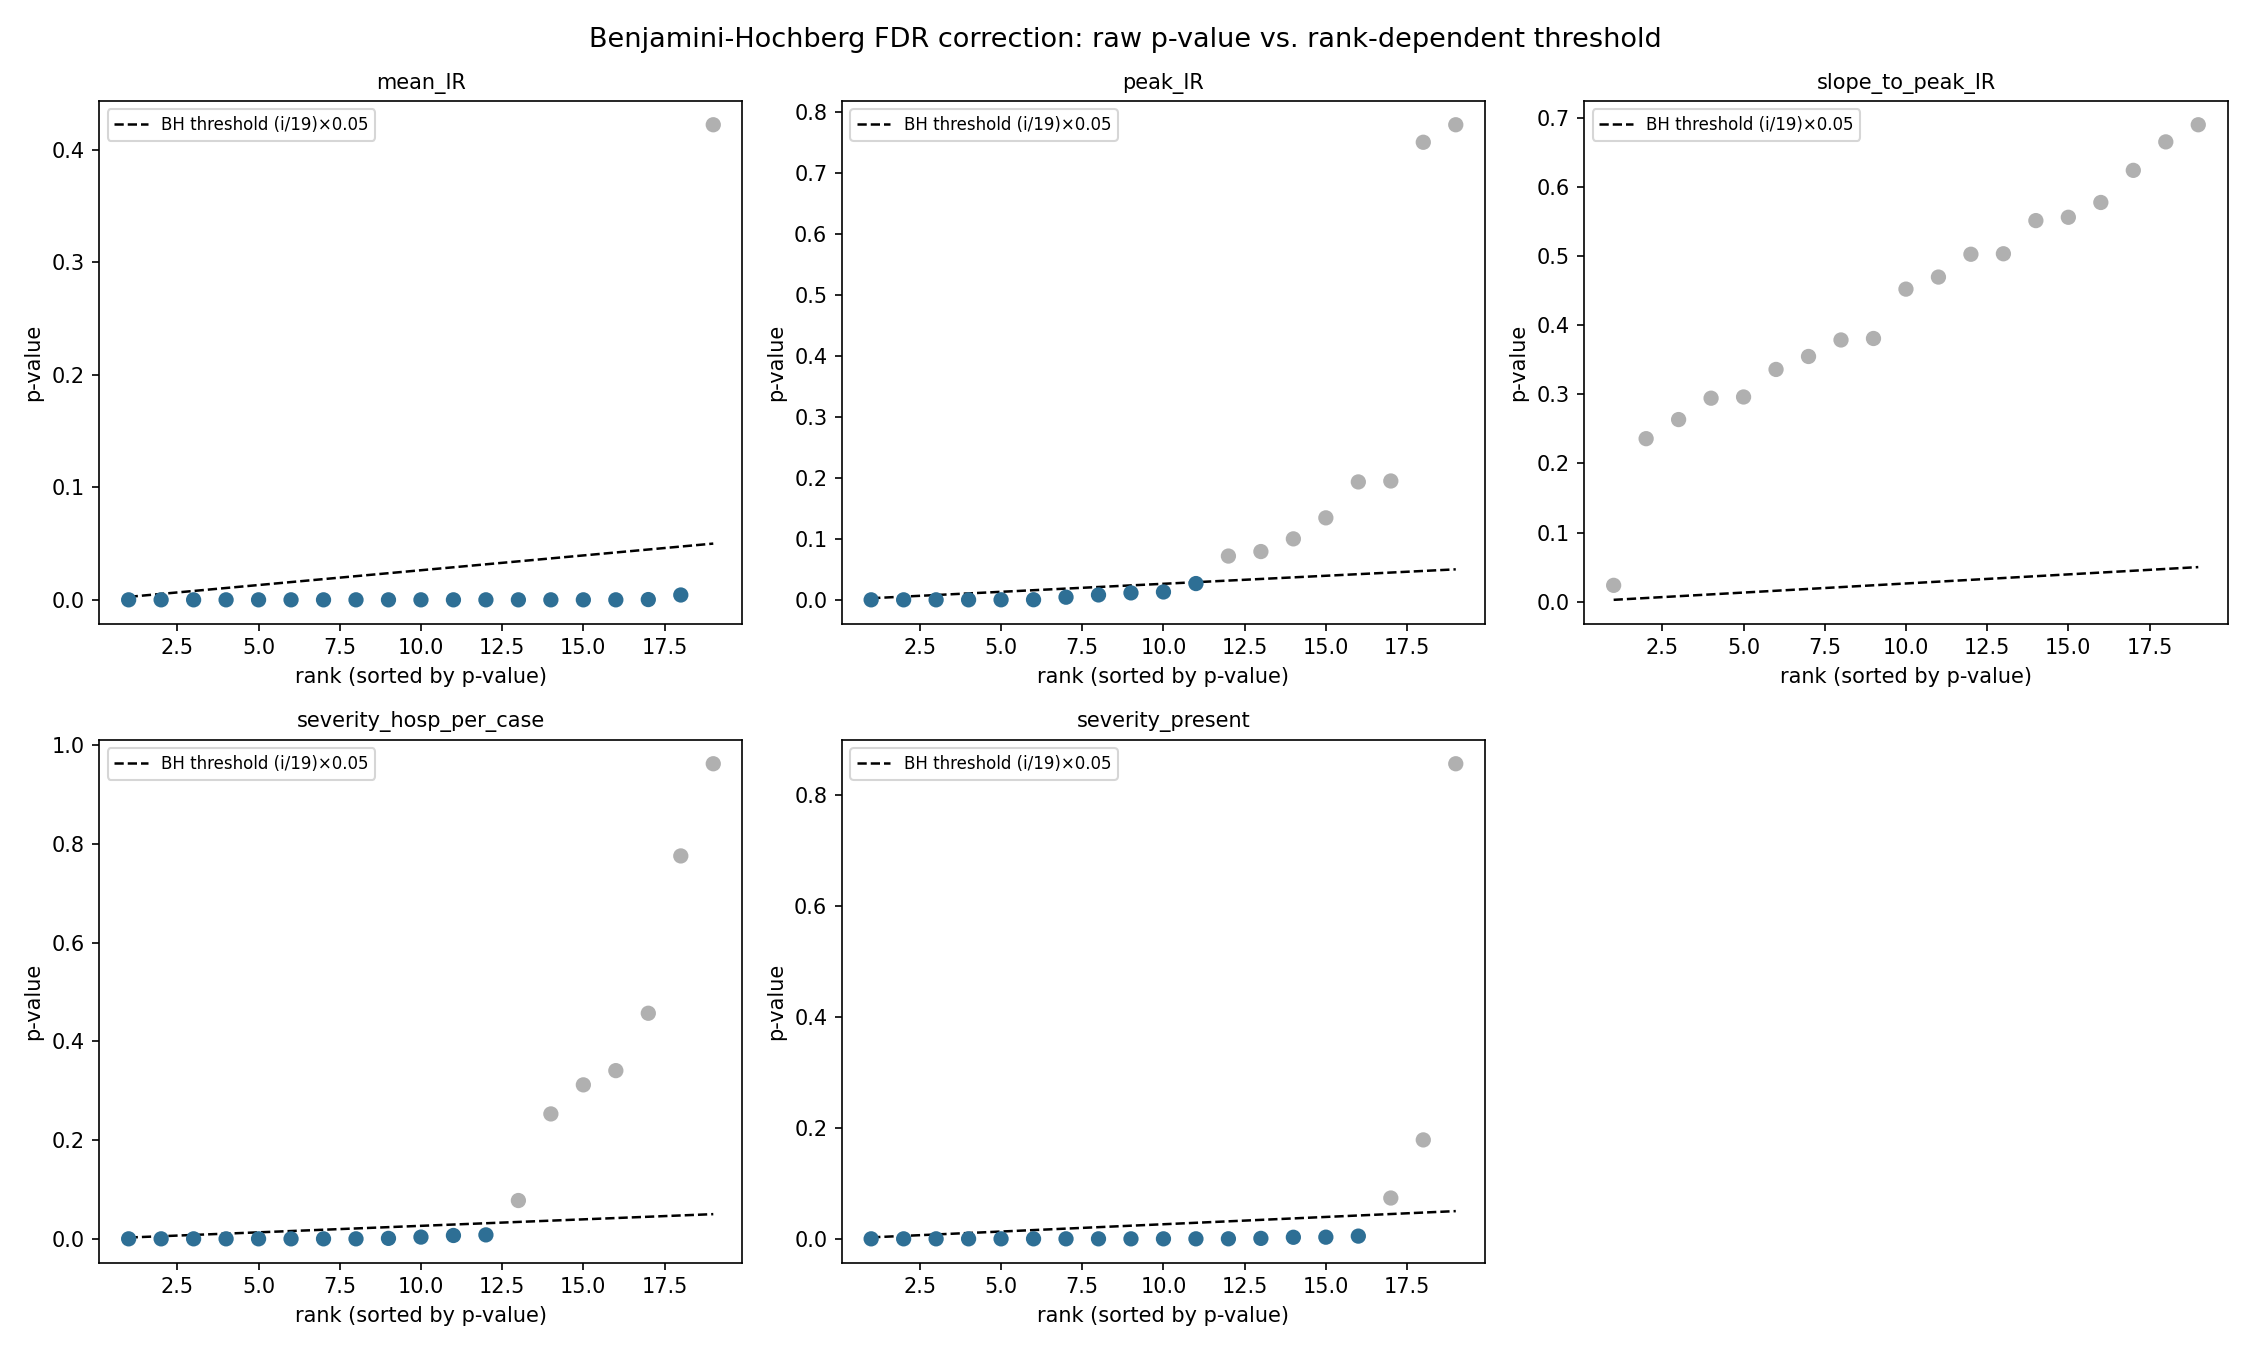

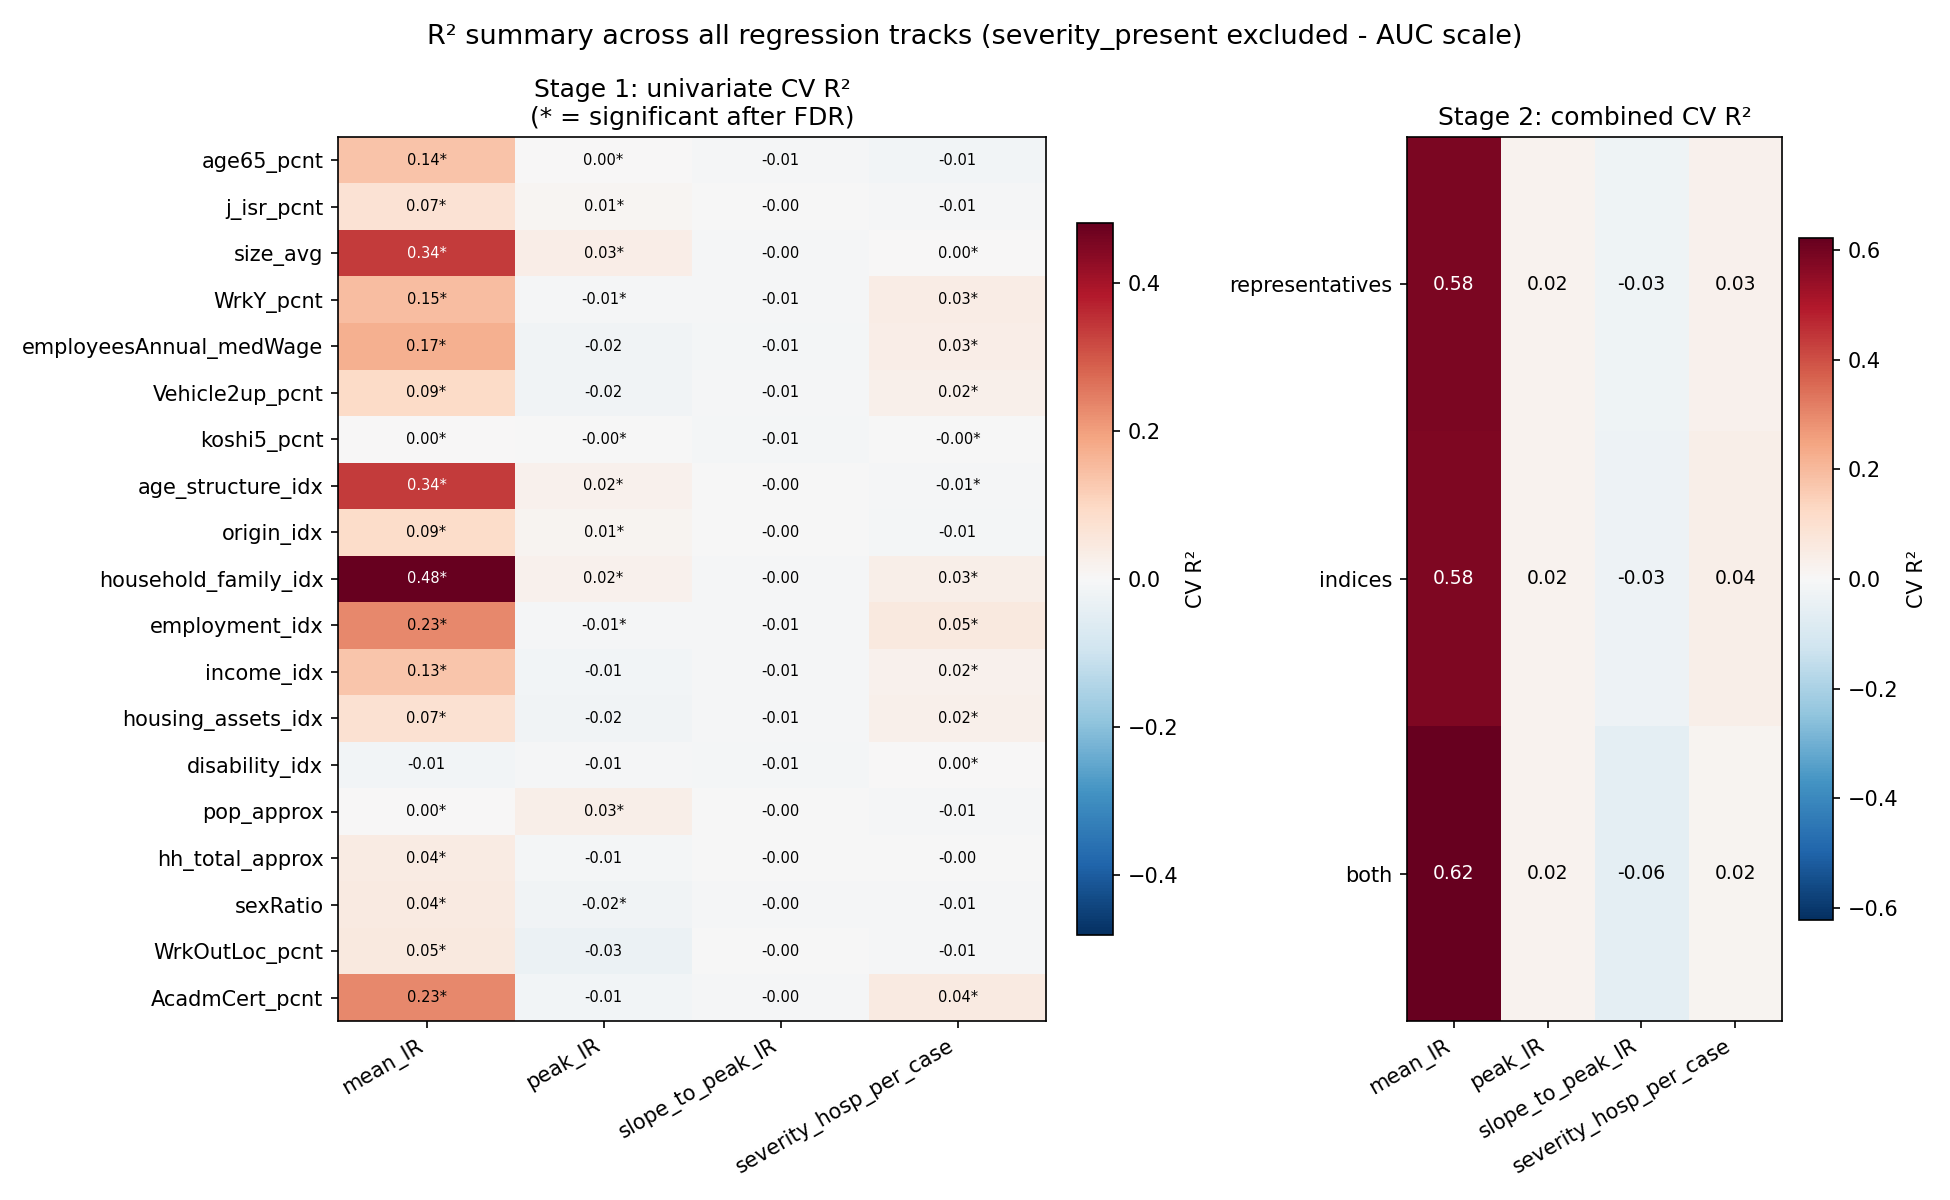

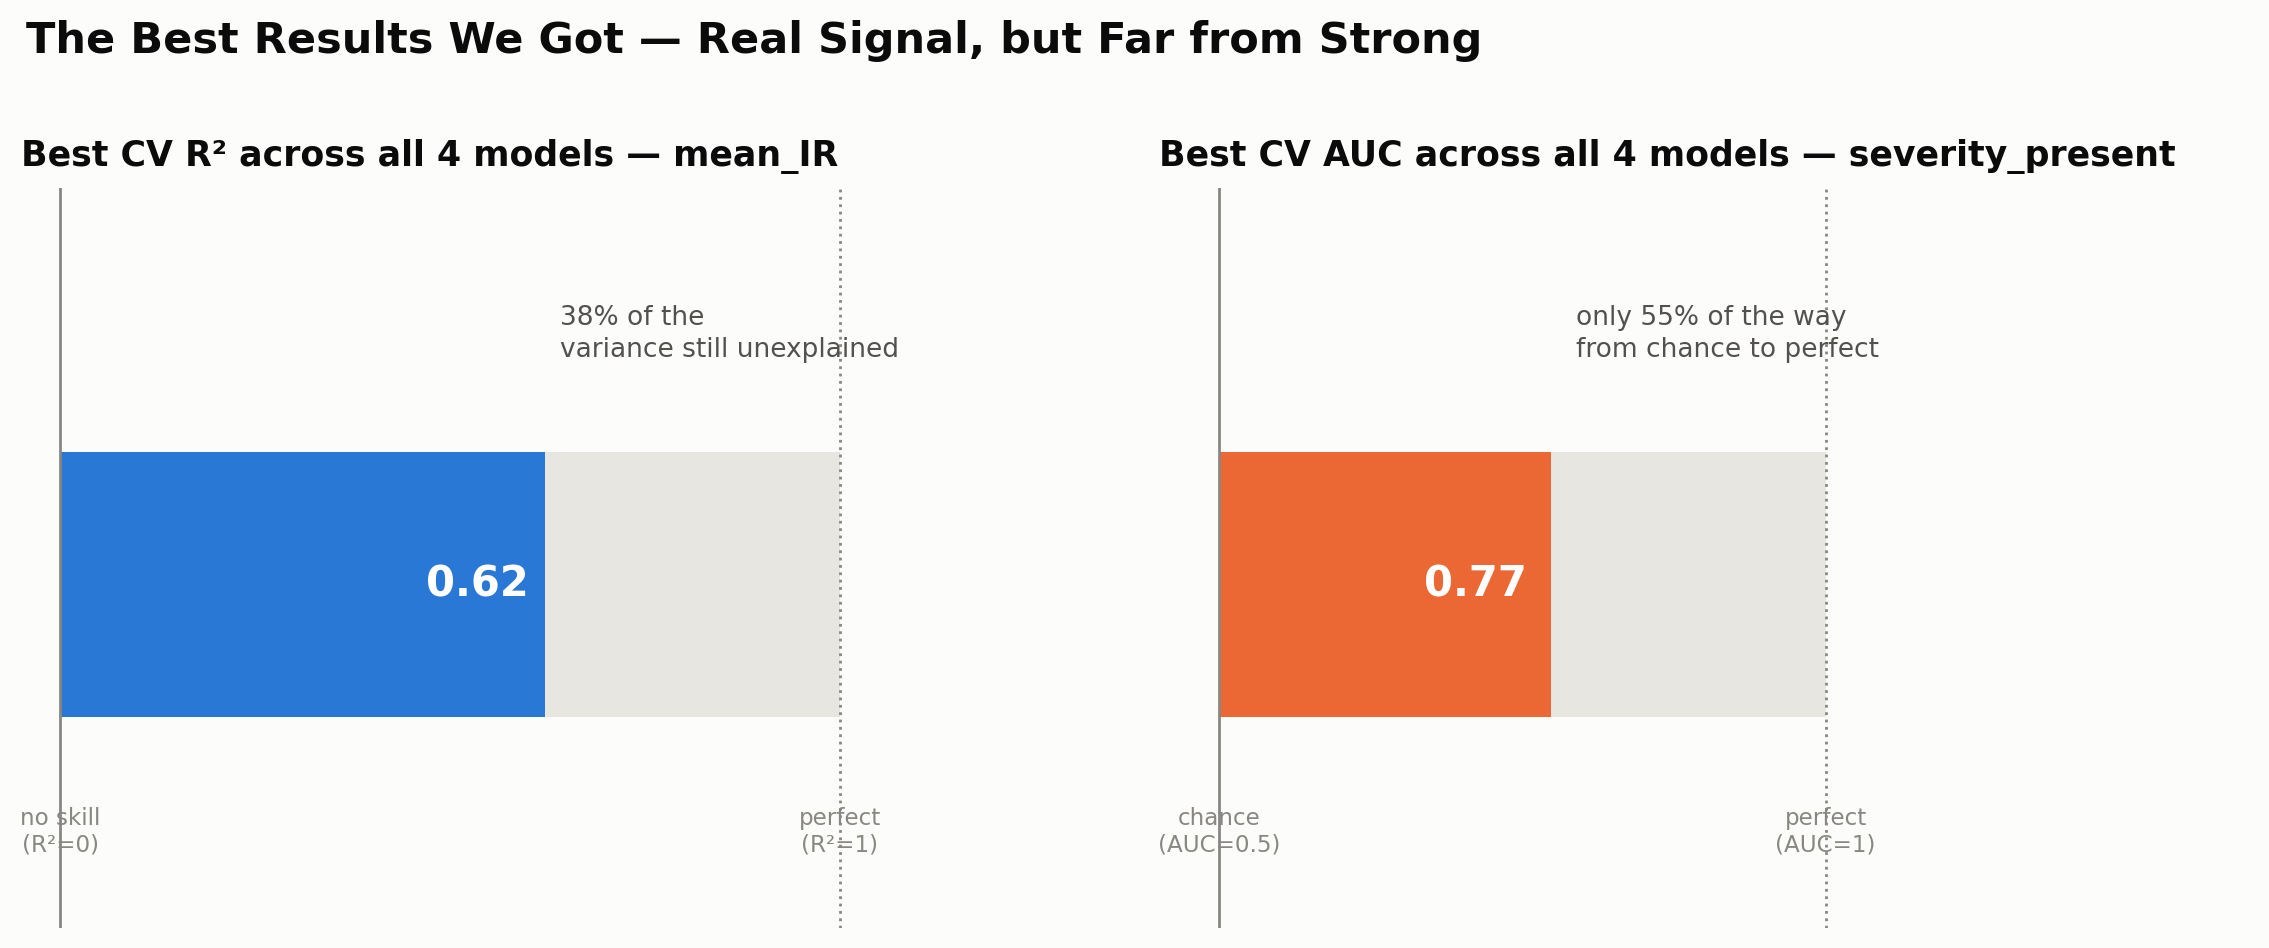

In [17]:
from IPython.display import Image, display
for f in ["overview_4_model_types.png", "model1_univariate_mean_IR.png",
          "model2_univariate_severity_present.png", "feature_target_correlation_heatmap.png",
          "combined_regression_summary.png", "combined_classification_summary.png",
          "fdr_correction_illustration.png", "results_summary_heatmap.png",
          "best_results_in_context.png"]:
    display(Image(filename=f"final_submission/figures/03_basic_models/{f}"))

## Performance & error analysis — what the baseline tells us

Read the committed numbers straight from the result tables:

In [18]:
import pandas as pd
uni = pd.read_csv("data/processed/models/wave2_univariate_screen_results.csv")
comb = pd.read_csv("data/processed/models/wave2_combined_regression_results.csv")

print("=== best univariate CV score per track (Stage 1) ===")
print(uni.sort_values("cv_score", ascending=False)
        .groupby("track", group_keys=False).head(1)
        [["track", "feature", "cv_score", "significant_fdr"]].to_string(index=False))

print("\n=== FDR-significant features per track ===")
print(uni[uni.significant_fdr].groupby("track").size().to_string())

print("\n=== combined models (Stage 2), best feature-set per track ===")
print(comb.sort_values("cv_score", ascending=False)
         .groupby("track", group_keys=False).head(1)
         [["track", "feature_set", "cv_score", "in_sample_score", "overfit_gap"]].to_string(index=False))

=== best univariate CV score per track (Stage 1) ===
                 track              feature  cv_score  significant_fdr
      severity_present household_family_idx  0.776146             True
               mean_IR household_family_idx  0.488656             True
severity_hosp_per_case       employment_idx  0.044889             True
               peak_IR             size_avg  0.035246             True
      slope_to_peak_IR       WrkOutLoc_pcnt -0.000283            False

=== FDR-significant features per track ===
track
mean_IR                   18
peak_IR                   11
severity_hosp_per_case    12
severity_present          16

=== combined models (Stage 2), best feature-set per track ===
                 track     feature_set  cv_score  in_sample_score  overfit_gap
      severity_present representatives  0.777849         0.806687     0.028838
               mean_IR            both  0.616669         0.660381     0.043712
severity_hosp_per_case         indices  0.041362       

### Reading of the results

* **Only `mean_IR` has real signal** — best single feature `household_family_idx`
  CV R² ≈ 0.48; combining all 19 features (Ridge, "both") lifts it to ≈ **0.62**,
  so ~38 % of between-area variance stays unexplained.
* **`severity_present`** is weakly predictable — CV **AUC ≈ 0.77** (16/19 features
  FDR-significant).
* **`peak_IR`, `slope_to_peak_IR`, `severity_hosp_per_case`** — essentially **no
  signal** (CV R² ≈ 0, sometimes negative); FDR removes almost every nominal hit.
* Combining features barely beats the best single feature → the ceiling is low, and
  the `overfit_gap` column shows the high-capacity fits are memorising the sample.

**Error-analysis conclusion.** A locality's static socio-economic structure explains
*part* of its average wave-2 infection level but says almost nothing about the shape
or severity of its wave. The signal that matters is **temporal**, not
cross-sectional → notebook 04 switches to the full daily time series and models the
dynamics directly.